# Ionosense-HPC: Processor Demo

This notebook demonstrates the core functionality of the `ionosense_hpc` library. We will:

1.  **Configure** the `Processor`.
2.  **Generate** a synthetic test signal.
3.  **Process** the signal in batches using the GPU.
4.  **Visualize** the resulting spectrum.
5.  **Analyze** performance statistics.

In [22]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Core components from our library
from ionosense_hpc import Processor, Presets, device_info
from ionosense_hpc.utils.signals import make_multitone

# Set a nice plot style
plt.style.use('seaborn-v0_8-whitegrid')

In [23]:
print("--- GPU Information ---")
info = device_info()
for key, value in info.items():
    print(f"{key:>20}: {value}")

# Load a configuration preset
config = Presets.realtime()
config.batch = 4 # Let's process 4 frames at a time

print("\n--- Processor Configuration ---")
print(config)

--- GPU Information ---
                  id: 0
                name: NVIDIA GeForce RTX 3090 Ti
     memory_total_mb: 24564
      memory_free_mb: 22313
  compute_capability: (8, 6)
       temperature_c: 39
             power_w: 101.921
     utilization_gpu: 1
  utilization_memory: 1

--- Processor Configuration ---
nfft=1024 batch=4 overlap=0.5 sample_rate_hz=48000 stream_count=3 pinned_buffer_count=2 warmup_iters=10 timeout_ms=100 use_cuda_graphs=False enable_profiling=False


Generated a signal with 24,000 samples.


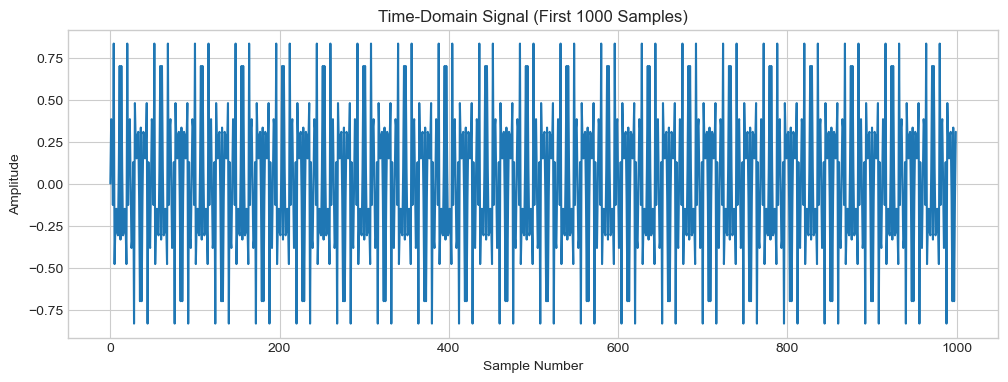

In [25]:
signal_duration_s = 0.5
frequencies = [5_000, 15_000, 27_000] # Frequencies in Hz

signal = make_multitone(
    frequencies=frequencies,
    duration=signal_duration_s, # CORRECTED: Changed 'duration_s' to 'duration'
    sample_rate=config.sample_rate_hz # CORRECTED: Changed 'sample_rate_hz' to 'sample_rate'
)

print(f"Generated a signal with {len(signal):,} samples.")

# Plot a small portion of the time-domain signal
plt.figure(figsize=(12, 4))
plt.plot(signal[:1000])
plt.title("Time-Domain Signal (First 1000 Samples)")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()

In [26]:
all_spectra = []
all_stats = []

# The 'with' statement ensures the GPU is properly managed
with Processor(config) as proc:
    # Process the signal in chunks (frames)
    num_frames = (len(signal) - config.nfft) // config.hop_size + 1
    
    for i in range(num_frames):
        start_idx = i * config.hop_size
        end_idx = start_idx + config.nfft
        frame = signal[start_idx:end_idx]
        
        # The core processing call
        # Since our config batch size is 4, we tile the frame to fill the batch
        input_batch = np.tile(frame, config.batch)
        spectrum_batch = proc.process(input_batch)
        
        # Store the first spectrum of the batch and the stats
        all_spectra.append(spectrum_batch[0, :])
        all_stats.append(proc.get_stats())

print(f"Processed {len(all_spectra)} frames.")
# Convert list of spectra into a 2D numpy array
spectrogram = np.array(all_spectra)

[2025-09-01 23:43:56,860] ionosense_hpc INFO: Initializing on device: NVIDIA GeForce RTX 3090 Ti
[2025-09-01 23:43:56,861] ionosense_hpc INFO:   Memory: 22283/24564 MB free
[2025-09-01 23:43:56,861] ionosense_hpc INFO:   Compute Capability: (8, 6)
[2025-09-01 23:43:56,865] ionosense_hpc INFO: Engine Configuration:
[2025-09-01 23:43:56,865] ionosense_hpc INFO:   FFT Size: 1024
[2025-09-01 23:43:56,866] ionosense_hpc INFO:   Batch Size: 4
[2025-09-01 23:43:56,866] ionosense_hpc INFO:   Sample Rate: 48000 Hz
[2025-09-01 23:43:56,868] ionosense_hpc INFO:   Overlap: 50.0%
[2025-09-01 23:43:56,868] ionosense_hpc INFO:   Output Bins: 513
[2025-09-01 23:43:56,869] ionosense_hpc INFO:   Frame Duration: 21.33 ms
[2025-09-01 23:43:56,869] ionosense_hpc INFO:   Hop Duration: 10.67 ms
[2025-09-01 23:43:56,870] ionosense_hpc INFO: Engine initialized with preset buffers: input=4096, output=2052
[2025-09-01 23:43:56,870] ionosense_hpc INFO: Running 10 warmup iterations...
[2025-09-01 23:43:56,887] ion

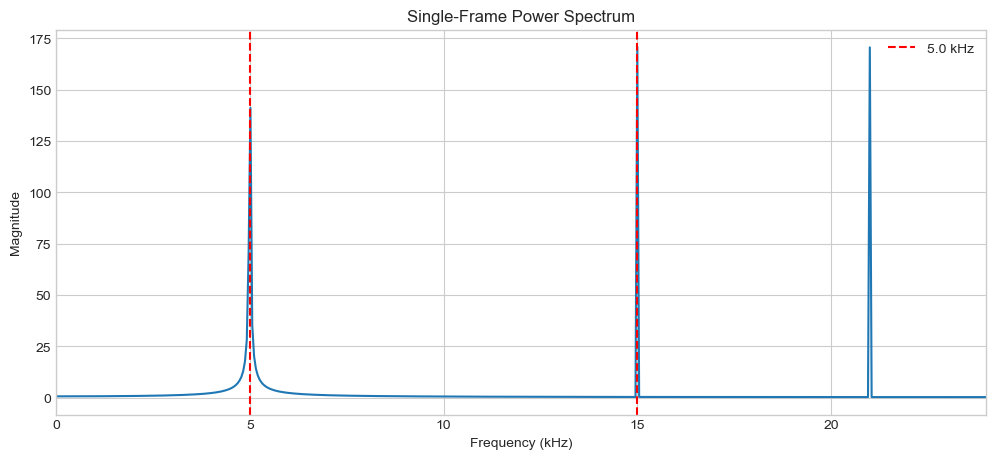

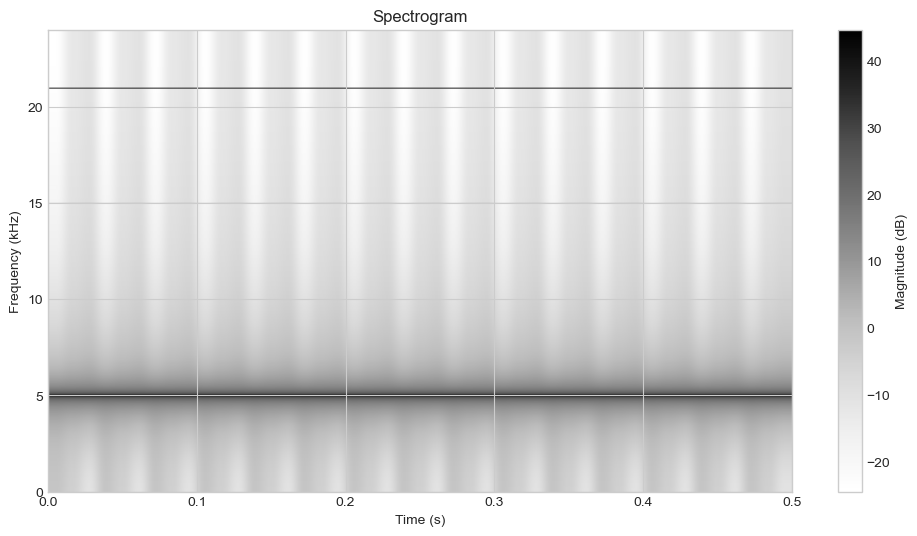

In [27]:
# Create the frequency axis for plotting
freq_axis = np.fft.rfftfreq(config.nfft, d=1./config.sample_rate_hz)

# 1. Plot the spectrum of a single frame
plt.figure(figsize=(12, 5))
plt.plot(freq_axis / 1000, spectrogram[len(spectrogram) // 2]) # Plot a middle frame
plt.title("Single-Frame Power Spectrum")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0, config.sample_rate_hz / 2000)
for f in frequencies:
    plt.axvline(f / 1000, color='r', linestyle='--', label=f'{f/1000} kHz' if f==frequencies[0] else "")
plt.legend()
plt.show()

# 2. Plot the spectrogram
plt.figure(figsize=(12, 6))
# Transpose so time is on the x-axis, and convert to dB for better visualization
db_spectrogram = 20 * np.log10(spectrogram.T + 1e-9)

plt.imshow(db_spectrogram, aspect='auto', origin='lower',
           extent=[0, signal_duration_s, 0, config.sample_rate_hz / 2000])

plt.colorbar(label="Magnitude (dB)")
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (kHz)")
plt.show()

--- Latency Statistics (microseconds) ---
count      45.000000
mean     1247.839998
std      1029.626963
min       150.899994
25%       631.799988
50%       773.599976
75%      2116.800049
max      4071.000000
Name: latency_us, dtype: float64


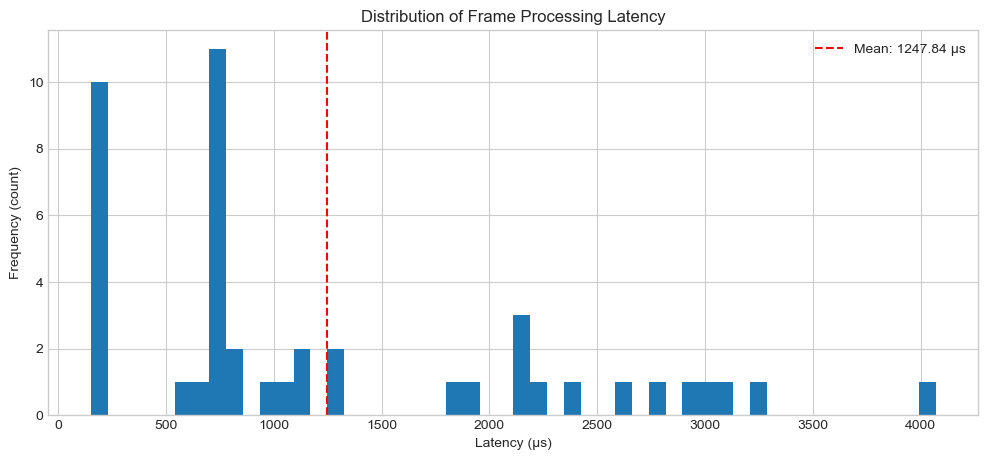

In [28]:
stats_df = pd.DataFrame(all_stats)

print("--- Latency Statistics (microseconds) ---")
print(stats_df['latency_us'].describe())

# Plot a histogram of the latencies
plt.figure(figsize=(12, 5))
stats_df['latency_us'].hist(bins=50)
plt.title("Distribution of Frame Processing Latency")
plt.xlabel("Latency (µs)")
plt.ylabel("Frequency (count)")

mean_lat = stats_df['latency_us'].mean()
plt.axvline(mean_lat, color='r', linestyle='--', label=f'Mean: {mean_lat:.2f} µs')
plt.legend()
plt.show()